In [2]:
## Creating tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper 

In [3]:
# Tool-1
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=5, doc_content_chars_max=200)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [4]:
arxiv.invoke('Redemption all you need')

'Published: 2020-05-14\nTitle: Street Marketing: How Proximity and Context drive Coupon Redemption\nAuthors: Sarah Spiekermann, Matthias Rothensee, Michael Klafft\nSummary: Purpose: In 2009, US coupons se'

In [5]:
# Tool-2
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [9]:
## Tavily Search tool 
# Tool-3
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [10]:
tavily.invoke('Provide me the recent ai news')

[{'title': 'Artificial intelligence | MIT News | Massachusetts Institute of Technology',
  'url': 'https://news.mit.edu/topic/artificial-intelligence2',
  'content': 'April 29, 2026\n\nRead full story →\n\nA large data center\n\n### A faster way to estimate AI power consumption\n\nThe “EnergAIzer” method generates reliable results in seconds, enabling data center operators to efficiently allocate resources and reduce wasted energy.\n\nApril 27, 2026\n\nRead full story →\n\nPlanet Earth against a background of math symbols\n\n### MIT scientists build the world’s largest collection of Olympiad-level math problems, and open it to everyone\n\nNew dataset of 30,000-plus competition math problems from 47 countries gives AI researchers a harder test — and students worldwide a better training ground.\n\nApril 24, 2026\n\nRead full story →\n\nAt left, a confused cartoon robot is thinking. At right, the same robot speaks confidently.\n\n### Teaching AI models to say “I’m not sure” [...] ### Teac

In [11]:
## combine all the tools in the list
tools = [arxiv, wiki, tavily]

In [12]:
## Initialize the llm model
from langchain_groq import ChatGroq

llm = ChatGroq(model='llama-3.1-8b-instant')

In [13]:
llm.invoke("What is AI")

AIMessage(content="AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is based on the principle of creating algorithms that enable computers to perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data, experiences, or interactions, and improve their performance over time.\n2. **Problem-solving**: AI systems can analyze complex problems, identify patterns, and find solutions.\n3. **Reasoning**: AI systems can draw conclusions, make inferences, and make decisions based on logic and evidence.\n4. **Perception**: AI systems can interpret and understand data from sensors, images, and other sources.\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak AI**: Designed to perform a sp

In [14]:
# llm will have the info about the tools
llm_with_tools = llm.bind_tools(tools=tools) 

In [15]:
# Excute the call
llm_with_tools.invoke("What is the recent news of ai?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jp16fhg7p', 'function': {'arguments': '{"query":"recent news ai"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 461, 'total_tokens': 481, 'completion_time': 0.039362074, 'completion_tokens_details': None, 'prompt_time': 0.026807686, 'prompt_tokens_details': None, 'queue_time': 0.050547693, 'total_time': 0.06616976}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de8c0-9cca-7353-93e0-ab7b2b11abae-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent news ai'}, 'id': 'jp16fhg7p', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 461, 'output_tokens': 20, 'total_tokens': 481})

## Workflow (LangGraph)

In [16]:
## State Schema
from typing_extensions import TypedDict 
from typing import Annotated ## Labelling
from langchain_core.messages import AnyMessage, HumanMessage ## AnyMessage : Human message or AI message
from langgraph.graph.message import add_messages ## Reducers in langGraph

In [17]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

    """ Reducers in LangGraph -> 
        - list[Anymessages] : it will append all the messages 
          whether it is ai or human with the help of the add_messages reducers.
        - add_messages reducer: It don't override the messages ; it 'append' the new message into messages
        - if we dont use the 'add_message' function then it will override the messages by adding list[AnyMessage]
          that appeares. 
    """

In [18]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition # for, when should we call the tool_node

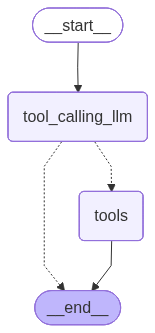

In [19]:
## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
# Run
messages = graph.invoke({"messages": "1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (7fq6bvhqv)
 Call ID: 7fq6bvhqv
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The do


In [ ]:
messages = graph.invoke({"messages": "Hi my name is Nick"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Nick
================================== Ai Message ==================================

I'm happy to chat with you, Nick. Is there something specific you'd like to talk about or ask about?


### ReAct Architecture

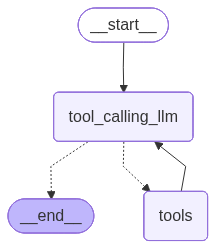

In [22]:
##  ReAct Architecture

## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm") # ***Going back to tool_calling_llm

# No need to add edge to 'End' it will go automatically//

graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
messages = graph.invoke({"messages": "What is the recent AI news and please tell me about the recent research paper on quantum computing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and please tell me about the recent research paper on quantum computing?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (v5cmvnfyq)
 Call ID: v5cmvnfyq
  Args:
    query: AI news recent
  arxiv (pn769kttq)
 Call ID: pn769kttq
  Args:
    query: quantum computing recent research paper
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest AI News, Developments, and Breakthroughs | 2026 | News", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "Summary: A recent study by Stanford University and Carnegie Mellon University (“Mellon/Stanford Study”) compared fully autonomous AI-agent workflows to hybrid workflows where humans and AI collaborate. The results show that while AI agents alone are much faster

### Adding Memory in Agentic Graph 

In [24]:
messages = graph.invoke({"messages": "Hello, my name is Nick"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Nick
================================== Ai Message ==================================

I'm happy to chat with you, Nick. Is there something I can help you with or would you like to explore a topic?


In [ ]:
# It is not able to answer based on the previous conversation now
messages = graph.invoke({"messages": "What is my name?"}) 
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (sdjw5dy8b)
 Call ID: sdjw5dy8b
  Args:
    query: your name
================================= Tool Message =================================
Name: wikipedia

Page: Your Name
Summary: Your Name (Japanese: 君の名は。, Hepburn: Kimi no Na wa; lit. 'Your Name is...') is a 2016 Japanese animated romantic fantasy film written and directed by Makoto Shinkai, produced 
================================== Ai Message ==================================

It seems like the previous function call returned a result for a movie, not a person's name. Let me try again.
Tool Calls:
  wikipedia (mhvn3x156)
 Call ID: mhvn3x156
  Args:
    query: your name
================================= Tool Message =================================
Name: wikipedia

Page: Your Name
Summary: Your Name (Japanese: 君の名は。, Hepburn

d:\C\GenAI and Agentic AI\LangGraph\.venv\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file d:\C\GenAI and Agentic AI\LangGraph\.venv\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


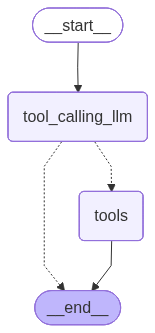

In [26]:
# Now, by using MemoryaSaver checkpoint
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Graph
## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# Add memory saver checkpoint
graph = builder.compile(checkpointer=memory)

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
config = {"configurable": {"thread_id": "1"}} # thread id should be unique

messages = graph.invoke({'messages': "Hi, my name is Nick"}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Nick
================================== Ai Message ==================================

Nice to meet you, Nick. Is there something I can help you with today?


In [29]:
messages['messages'][-1]

AIMessage(content='Nice to meet you, Nick. Is there something I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 459, 'total_tokens': 477, 'completion_time': 0.024407042, 'completion_tokens_details': None, 'prompt_time': 0.026025911, 'prompt_tokens_details': None, 'queue_time': 0.052681685, 'total_time': 0.050432953}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de8d0-4d7d-74f0-aba9-d45853e30145-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 459, 'output_tokens': 18, 'total_tokens': 477})

In [ ]:
messages = graph.invoke({'messages': "What is my name?"}, config=config)

messages['messages'][-1]
# Now it can remember your name

AIMessage(content='I think we already figured it out. Your name is Nick.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 665, 'total_tokens': 679, 'completion_time': 0.02987963, 'completion_tokens_details': None, 'prompt_time': 0.041446598, 'prompt_tokens_details': None, 'queue_time': 0.054931691, 'total_time': 0.071326228}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de8d3-5211-7691-9fe7-8cf71f1a1b9e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 665, 'output_tokens': 14, 'total_tokens': 679})

In [34]:
messages = graph.invoke({'messages': "Do you remember my name?"}, config=config)

messages['messages'][-1]

AIMessage(content='Yes, I remember that your name is Nick.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 694, 'total_tokens': 705, 'completion_time': 0.014478359, 'completion_tokens_details': None, 'prompt_time': 0.042919988, 'prompt_tokens_details': None, 'queue_time': 0.052639765, 'total_time': 0.057398347}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de8d4-1590-7c61-98d3-bf9d6e3f3472-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 694, 'output_tokens': 11, 'total_tokens': 705})